# Turn-level rubric score plots for static_eval

This notebook loads utterance-level label outputs from `src/eval/utterance_labeler.py` and makes simple turn-by-turn plots. It is intentionally small and focused: configure a labels path, inspect the data, optionally filter it, and compare rubric scores across doctor personalities and patient personas.

## Quick workflow: simulation → utterance labeling → notebook

Use this notebook after you already created one dialogue file and one label file. The flow is:

1. Run `run_simulation.py` from `PatientSim/src` to create `results/<exp_name>/outputs/dialogue.jsonl`.
2. Run `eval/utterance_labeler.py` on that experiment to create `results/<exp_name>/outputs/eval/utterance_labeler/labels__<labeler>.jsonl`.
3. Open this notebook and set `EXP_NAME` / `LABELER_TAG` below to the same run.

Example commands:

```bash
cd /home/edlab/ceshim/PatientSim/src

uv run python run_simulation.py \
  experiment.exp_name=gpt5mini_static_eval_demo_tempfix \
  data.num_scenarios=1 \
  doctor_agent.api_type=gpt_azure \
  doctor_agent.backend=gpt-5-mini \
  doctor_agent.personality_type=incompetent \
  doctor_agent.params.temperature=1.0 \
  patient_agent.api_type=gpt_azure \
  patient_agent.backend=gpt-5-mini \
  patient_agent.params.temperature=1.0

uv run python eval/utterance_labeler.py \
  --result_dir results \
  --trg_exp_name 2026-04-08-17-46-34_gpt5mini_static_eval_demo_tempfix \ 
  --labeler gpt-5-mini \
  --labeler_api_type gpt_azure \
  --temperature 1.0 \
  --overwrite
```

If you generate a new run, update `EXP_NAME` below before plotting.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('default')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)

## 1) Configure the labels file

Edit the variables below to point at one `labels__*.jsonl` file produced by the utterance labeler. The default path follows the output structure used in `PatientSim/src/eval/utterance_labeler.py`.

In [3]:
repo_root = Path.cwd().resolve()
if repo_root.name == 'notebooks':
    repo_root = repo_root.parent

RESULT_DIR = repo_root / 'src' / 'results'
EXP_NAME = '2026-04-08-17-46-34_gpt5mini_static_eval_demo_tempfix'
LABELER_TAG = 'gpt-5-mini'

LABELS_PATH = RESULT_DIR / EXP_NAME / 'outputs' / 'eval' / 'utterance_labeler' / f'labels__{LABELER_TAG}.jsonl'
# LABELS_PATH = Path('/absolute/path/to/labels__gpt-5-mini.jsonl')

LABELS_PATH

PosixPath('/home/edlab/ceshim/PatientSim/src/results/2026-04-08-17-46-34_gpt5mini_static_eval_demo_tempfix/outputs/eval/utterance_labeler/labels__gpt-5-mini.jsonl')

## 2) Load the JSONL and inspect the columns

Each row should represent one patient turn. This cell loads the file, finds the available `*_score` columns, and shows a small preview so you can confirm the schema before plotting.

In [4]:
if not LABELS_PATH.exists():
    raise FileNotFoundError(f'Labels file not found: {LABELS_PATH}')

df = pd.read_json(LABELS_PATH, lines=True)
df['turn'] = pd.to_numeric(df['turn'], errors='coerce')

score_columns = sorted(col for col in df.columns if col.endswith('_score'))
required_columns = [
    'turn',
    'doctor_personality',
    'personality_type',
    'cefr_type',
    'recall_level_type',
    'dazed_level_type',
]

preview_columns = [col for col in required_columns + score_columns if col in df.columns]

print(f'Loaded rows: {len(df):,}')
print(f'Available score columns: {score_columns}')
print('Missing expected metadata columns:', [col for col in required_columns if col not in df.columns])

display(df[preview_columns].head())
display(pd.DataFrame({'column': df.columns}).head(30))

Loaded rows: 9
Available score columns: ['anxiety_score', 'doubt_score', 'impatience_score', 'minimization_score', 'satisfaction_score']
Missing expected metadata columns: []


,turn,doctor_personality,personality_type,cefr_type,recall_level_type,dazed_level_type,anxiety_score,doubt_score,impatience_score,minimization_score,satisfaction_score
0,1,incompetent,distrust,B,low,normal,3,3,4,1,2
1,2,incompetent,distrust,B,low,normal,2,3,3,3,2
2,3,incompetent,distrust,B,low,normal,2,3,4,2,2
3,4,incompetent,distrust,B,low,normal,1,3,4,3,2
4,5,incompetent,distrust,B,low,normal,1,2,3,3,2


,column
0,hadm_id
1,experiment_name
2,source_dialogue_file
3,patient_engine_name
4,doctor_engine_name
5,patient_api_type
6,doctor_api_type
7,patient_prompt_file
8,doctor_prompt_file
9,doctor_personality


## 3) Optional filters

Leave a filter as `None` to keep all rows. Use lists to focus on a subset, for example one CEFR level or one doctor personality. The notebook averages scores over any rows that remain after filtering.

In [5]:
KEEP_DOCTOR_PERSONALITIES = None
KEEP_PERSONALITY_TYPES = None
KEEP_CEFR_TYPES = None
KEEP_RECALL_LEVEL_TYPES = None
KEEP_DAZED_LEVEL_TYPES = None
MAX_TURN = None
SCORE_COLUMNS_TO_PLOT = None

filtered_df = df.copy()

filters = {
    'doctor_personality': KEEP_DOCTOR_PERSONALITIES,
    'personality_type': KEEP_PERSONALITY_TYPES,
    'cefr_type': KEEP_CEFR_TYPES,
    'recall_level_type': KEEP_RECALL_LEVEL_TYPES,
    'dazed_level_type': KEEP_DAZED_LEVEL_TYPES,
}

for column, values in filters.items():
    if values is not None:
        filtered_df = filtered_df[filtered_df[column].isin(values)].copy()

if MAX_TURN is not None:
    filtered_df = filtered_df[filtered_df['turn'] <= MAX_TURN].copy()

selected_score_columns = SCORE_COLUMNS_TO_PLOT or score_columns
if not selected_score_columns:
    raise ValueError('No *_score columns were found in the labels file.')
if filtered_df.empty:
    raise ValueError('No rows remain after filtering. Relax one or more filters and run again.')

print(f'Rows after filtering: {len(filtered_df):,}')
print('Doctor personalities:', sorted(filtered_df['doctor_personality'].dropna().unique()))
print('Patient personas:', sorted(filtered_df['personality_type'].dropna().unique()))
print('CEFR types:', sorted(filtered_df['cefr_type'].dropna().unique()))
print('Recall levels:', sorted(filtered_df['recall_level_type'].dropna().unique()))
print('Dazed levels:', sorted(filtered_df['dazed_level_type'].dropna().unique()))
print('Scores to plot:', selected_score_columns)

Rows after filtering: 9
Doctor personalities: ['incompetent']
Patient personas: ['distrust']
CEFR types: ['B']
Recall levels: ['low']
Dazed levels: ['normal']
Scores to plot: ['anxiety_score', 'doubt_score', 'impatience_score', 'minimization_score', 'satisfaction_score']


## 4) Plot by patient persona (compact score grid; one panel per persona, one line per doctor personality)

This view keeps the same comparison logic as before, but packs multiple score dimensions into one wrapped figure. Within each score block, panels are split by patient persona and each point is the mean score for the remaining rows in that `(turn, doctor_personality, personality_type)` group.

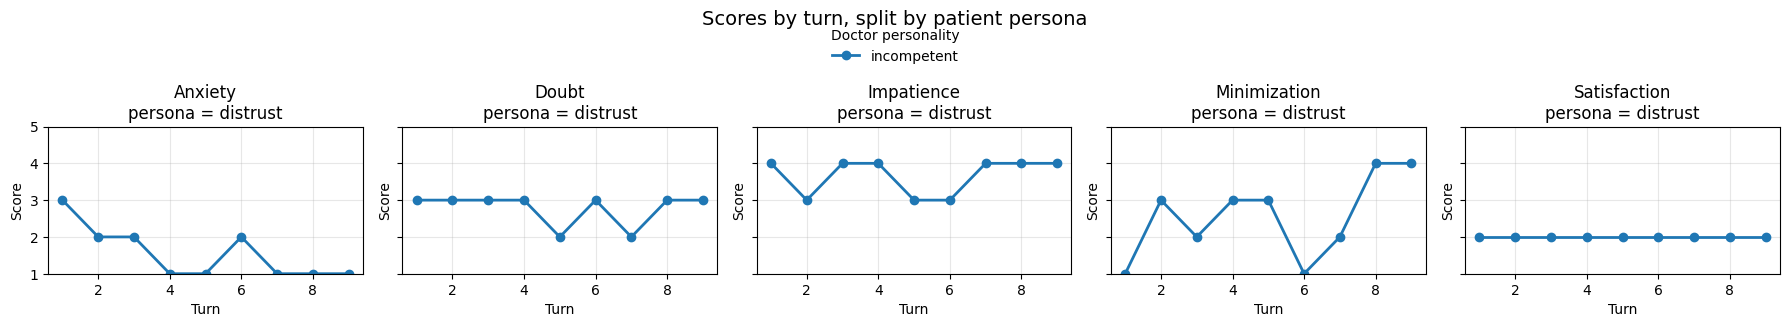

In [8]:
plot_df = filtered_df.groupby(['turn', 'doctor_personality', 'personality_type'], dropna=False)[selected_score_columns].mean().reset_index()
personas = sorted(plot_df['personality_type'].dropna().unique())
doctor_personalities = sorted(plot_df['doctor_personality'].dropna().unique())

def pretty_score_name(score_col):
    return score_col.replace('_score', '').replace('_', ' ').title()

def plot_compact_score_grid(plot_df, score_columns, panel_column, line_column, panel_values, line_values, figure_title, panel_label, legend_title, max_total_columns=6):
    panel_count = max(len(panel_values), 1)
    score_blocks_per_row = max(1, min(len(score_columns), max_total_columns // panel_count or 1))
    row_count = (len(score_columns) + score_blocks_per_row - 1) // score_blocks_per_row
    total_columns = score_blocks_per_row * panel_count

    fig, axes = plt.subplots(
        row_count,
        total_columns,
        figsize=(3.6 * total_columns, 3.1 * row_count),
        sharex=True,
        sharey=True,
        squeeze=False,
    )

    legend_handles = None
    legend_labels = None

    for score_index, score_col in enumerate(score_columns):
        row_index = score_index // score_blocks_per_row
        block_index = score_index % score_blocks_per_row
        block_start = block_index * panel_count

        for panel_offset, panel_value in enumerate(panel_values):
            ax = axes[row_index, block_start + panel_offset]
            panel_df = plot_df[plot_df[panel_column] == panel_value]

            for line_value in line_values:
                line_df = panel_df[panel_df[line_column] == line_value].sort_values('turn')
                if line_df.empty:
                    continue
                ax.plot(line_df['turn'], line_df[score_col], marker='o', linewidth=2, label=line_value)

            ax.set_title(f'{pretty_score_name(score_col)}\n{panel_label} = {panel_value}')
            ax.set_xlabel('Turn')
            ax.set_ylim(1, 5)
            ax.set_yticks([1, 2, 3, 4, 5])
            ax.grid(True, alpha=0.3)
            if panel_offset == 0:
                ax.set_ylabel('Score')
            if legend_handles is None:
                legend_handles, legend_labels = ax.get_legend_handles_labels()

    for empty_index in range(len(score_columns), row_count * score_blocks_per_row):
        row_index = empty_index // score_blocks_per_row
        block_index = empty_index % score_blocks_per_row
        block_start = block_index * panel_count
        for panel_offset in range(panel_count):
            axes[row_index, block_start + panel_offset].set_visible(False)

    if legend_handles:
        fig.legend(legend_handles, legend_labels, title=legend_title, loc='upper center', ncol=min(len(legend_labels), 4), frameon=False, bbox_to_anchor=(0.5, 1.02))

    fig.suptitle(figure_title, y=1.04, fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

plot_compact_score_grid(
    plot_df=plot_df,
    score_columns=selected_score_columns,
    panel_column='personality_type',
    line_column='doctor_personality',
    panel_values=personas,
    line_values=doctor_personalities,
    figure_title='Scores by turn, split by patient persona',
    panel_label='persona',
    legend_title='Doctor personality',
    max_total_columns=6,
)

## 5) Plot by doctor personality (compact score grid; one panel per doctor personality, one line per patient persona)

This is the complementary view in the same compact layout: each score block is wrapped into the same figure, each panel fixes one doctor personality, and the lines compare patient personas within that doctor condition.

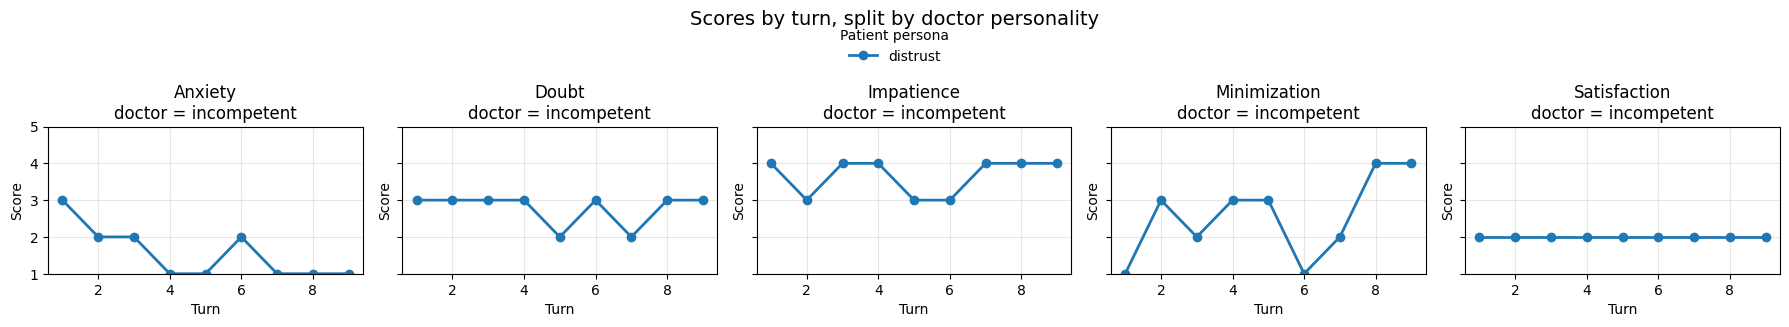

In [9]:
plot_compact_score_grid(
    plot_df=plot_df,
    score_columns=selected_score_columns,
    panel_column='doctor_personality',
    line_column='personality_type',
    panel_values=doctor_personalities,
    line_values=personas,
    figure_title='Scores by turn, split by doctor personality',
    panel_label='doctor',
    legend_title='Patient persona',
    max_total_columns=6,
)